In [2]:
# Confirm that JSBSim is installed. If not and running on Google Colab
# then install JSBSim into the Google Colab instance.

import os
from pathlib import Path

try:
  import jsbsim
  print('JSBSim is installed')
  # Relative path to the directory where the flight model is stored
  # Note - Aircraft directory needs to be writeable in order to modify the cg
  PATH_TO_JSBSIM_FILES= str(Path.cwd().parent.parent.parent / "jsbsim")
  #print(f'Current working directory: {os.getcwd()}')
except ImportError:
  import sys
  if 'google.colab' in sys.modules:
      print('Installing JSBSim...')
      %pip install jsbsim
      # Use the standard aircraft supplied by the JSBSim Python package
      PATH_TO_JSBSIM_FILES=None

JSBSim is installed


In [76]:
import matplotlib.pyplot as plt
import math
# --- Configuration Section ---
# Global variables that must be modified to match your particular need
# The aircraft name
# Note - It should match the exact spelling of the model file
AIRCRAFT_NAME="A4"

# --- JSBSim Initialization ---
# These lines initialize the flight dynamics model.

# Avoid flooding the console with log messages
jsbsim.FGJSBBase().debug_lvl = 0

# Create a flight dynamics model (FDM) instance.
fdm = jsbsim.FGFDMExec(PATH_TO_JSBSIM_FILES)

# Load the aircraft model
fdm.load_model(AIRCRAFT_NAME)

True

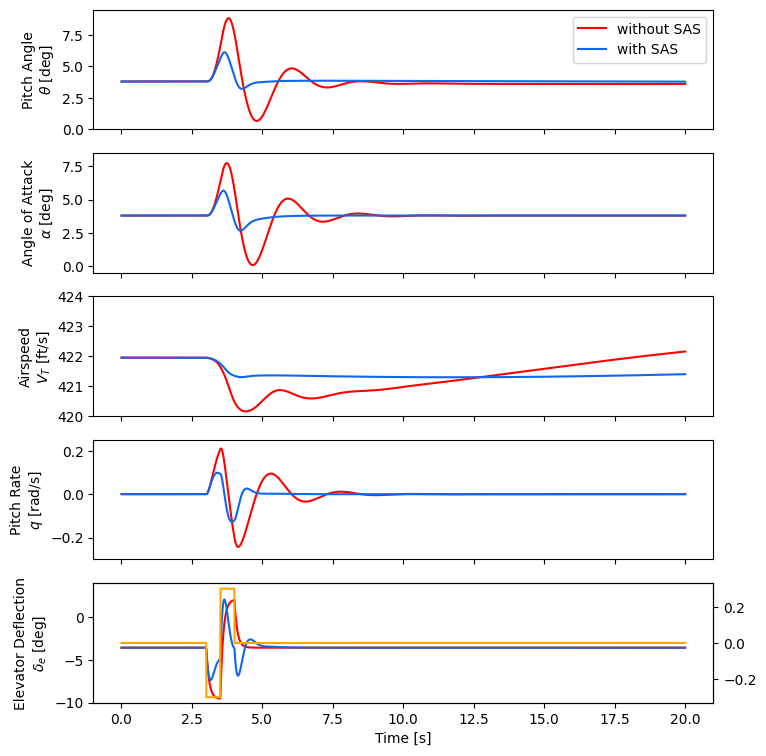

In [ ]:
def run_simu(sas_active):

    fdm.reset_to_initial_conditions(0)
    # Set engines running
    #fdm['propulsion/engine[0]/throttle-cmd-norm'] = 0.5  # 50% throttle
    fdm['propulsion/engine[0]/set-running'] = 1 # always motor running?
    # Get the simulation time step (delta time).
    dt = fdm.get_delta_t()
    

    # --- Data Storage ---
    # This section initializes lists to record simulation data.
    data = { 'times':[],
             'thetas': [],
             'alphas': [],
             'airspeeds': [],
             'pitchRates': [],
             'elevator_pos': [],
             'elevator_commands': []
             }

    # --- Simulation Initialization ---
    # This line initializes the flight dynamics model.

    # Initial conditions
    fdm['ic/h-sl-ft']   = 8000  #altitude above sea level (ft)
    fdm['ic/vt-kts']    = 250    #calibrated airspeed (kts)
    fdm['ic/gamma-deg'] = 0   #flight path angle (deg)
    fdm['ic/beta-deg']  = 0    #sideslip angle (deg)

    # Initialize the aircraft with initial conditions
    fdm.run_ic()

    # Attempt to trim the aircraft.
    try:
        # 1 means straight flight by using all changeable control variables.
        #fdm['simulation/sim-time-sec'] = 0.0
        fdm['simulation/do_simple_trim'] = 1

    except jsbsim.TrimFailureError:
        print("Trim failed, continuing rudder kick in an untrimmed state.")
        pass  # Ignore trim failure

    # --- Simulation Loop ---
    # This is the main simulation loop that runs the simulation for a specified duration.

    # Time to run for in seconds.
    run_period = 20

    # Start the doublet 2 seconds into the simulation to ensure we are in a steady trim.
    doublet_start_time = 3.0  
    doublet_width = 0.5       # Duration of each pulse in seconds.
    doublet_amplitude = 0.3   # Magnitude of the elevator deflection (normalized -1 to 1).

    for i in range(int(run_period/dt)):
        # Advance the simulation by one time step.
        fdm.run()
        
        # Record the simulation data.
        data['times'].append(fdm.get_sim_time())
        data['thetas'].append(fdm['attitude/theta-deg'])
        data['alphas'].append(fdm['aero/alpha-deg'])
        data['airspeeds'].append(fdm['velocities/vt-fps'])
        data['pitchRates'].append(fdm['velocities/q-rad_sec']) 
        data['elevator_commands'].append(fdm['fcs/elevator-cmd-norm'])
        data['elevator_pos'].append(fdm['fcs/elevator-pos-deg'])
        
        fdm['fcs/sas-active-switch'] = sas_active
        # 2. Get the current simulation time to determine which part of the doublet we are in.
        current_time = fdm.get_sim_time()

        # 3. Doublet Logic: We define three distinct phases.
        # Phase A: The first "up" pulse (positive pitch/negative elevator).
        if doublet_start_time <= current_time < (doublet_start_time + doublet_width):
            elevator_cmd = -doublet_amplitude  # Typical "pull" for pitch up.

        # Phase B: The second "down" pulse (immediate reversal).
        elif (doublet_start_time + doublet_width) <= current_time < (doublet_start_time + 2 * doublet_width):
            elevator_cmd = doublet_amplitude   # Typical "push" for pitch down.

        # Phase C: Return to neutral (trim) to observe the natural damping of the aircraft.
        else:
            elevator_cmd = 0.0

        # 4. Apply the command to the elevator property.
        # JSBSim uses 'fcs/elevator-cmd-norm' as the standard input for elevator control.
        fdm['fcs/elevator-cmd-norm'] = elevator_cmd
    
    return data

no_sas = run_simu(sas_active=0)
with_sas = run_simu(sas_active=1)
   
# --- Plot Results ---
# This section plots the simulation results.

#plt.rcParams["figure.figsize"] = (12, 8) # Set the figure size.
fig, axes = plt.subplots(5,1,figsize=(8,9),sharex=True)
ax_theta, ax_alpha, ax_vt, ax_q, ax_elev = axes

color2 = "#FF0000" # Cyan (Signal A) | #409DE9 | #007FFF No SAS   00FFFF
color1 = "#0F67EB" # Magenta (Signal B) | #BF00FF #FF8C00 SAS
lw1 = 1.5
lw2 = 1.5
# setup individual lines and labels
ax_theta.plot(no_sas['times'],no_sas['thetas'], color= color2, linewidth=lw1, label="without SAS")
ax_alpha.plot(no_sas['times'],no_sas['alphas'], color= color2,linewidth=lw1)
ax_vt.plot(no_sas['times'],no_sas['airspeeds'], color= color2,linewidth=lw1)
ax_q.plot(no_sas['times'],no_sas['pitchRates'], color= color2,linewidth=lw1)
ax_elev.plot(no_sas['times'],no_sas['elevator_pos'], color= color2,linewidth=lw1)

# setup individual lines and labels
ax_theta.plot(with_sas['times'],with_sas['thetas'], color= color1, linewidth=lw1, label="with SAS")
ax_alpha.plot(with_sas['times'],with_sas['alphas'], color= color1,linewidth=lw1)
ax_vt.plot(with_sas['times'],with_sas['airspeeds'], color= color1,linewidth=lw1)
ax_q.plot(with_sas['times'],with_sas['pitchRates'], color= color1,linewidth=lw1)
ax_elev.plot(with_sas['times'],with_sas['elevator_pos'], color= color1,linewidth=lw1)

ax_theta.legend(loc='upper right')

ax_theta.set_ylim(0, 9.5)
ax_alpha.set_ylim(-0.5,8.5)
ax_vt.set_ylim(420,424)
ax_q.set_ylim(-0.3, 0.25)
ax_elev.set_ylim(-10,4) #(-0.14,0.25)    
ax_elev.set_xlabel("Time [s]")
#ax_elev.set_xlim(0,15)

ax2 = ax_elev.twinx()
ax2.plot(no_sas['times'], no_sas['elevator_commands'], label='elevator cmd', color='orange')

#labels 
labels = ["Pitch Angle" + "\n" + r"$\theta$ [deg]", "Angle of Attack" + "\n" + r"$\alpha$ [deg]", 
          "Airspeed" + "\n" + r"$V_T$ [ft/s]", "Pitch Rate" + "\n" + r"$q$ [rad/s]", 
          "Elevator Deflection" + "\n" + r"$\delta_e$ [deg]"]

for ax,label in zip(axes, labels):
    ax.set_ylabel(label)

# Display the plot.
plt.show()